In [3]:
#group similar customers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.simplefilter('ignore')

In [4]:

df=pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.drop('CustomerID',axis = 1,inplace = True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.shape

(200, 5)

df.isnull().sum()

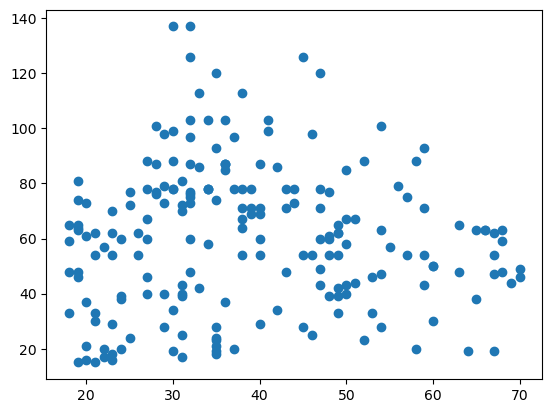

In [7]:
a = df.iloc[:,2] #give me all rows of the 3rd column
b = df.iloc[:,3]
plt.scatter(a,b)
plt.show()

# modeling

In [8]:
X = df.iloc[:, [2,3]].values #multiple specific columns

In [10]:
from sklearn.cluster import KMeans

In [11]:
#This data is then plotted (WCSS vs. k) to visually find the "elbow" point — the optimal number of clusters for your dataset.
WCSS = []
for i in range (1,11):
    kmeans = KMeans(n_clusters = i , init = 'k-means++', random_state = 42) #smart initialization method that spreads out the initial centroids
    kmeans.fit(X)
    #within-cluster sum of squares
    WCSS.append(kmeans.inertia_) #  is an attribute that gives you a single number representing how well the clustering fit the data


In [12]:
WCSS

[176108.77999999997,
 87121.56591478697,
 59486.96143928035,
 39529.8879673635,
 31674.906249279375,
 25643.265320259467,
 21839.635516285518,
 18808.749269005846,
 16044.79169532817,
 13912.451770855003]

# elbow curve

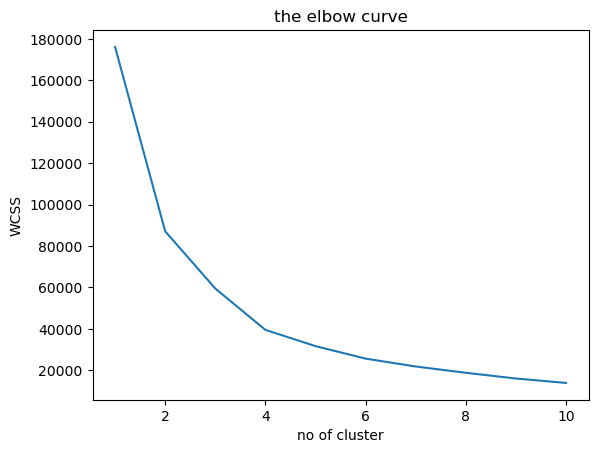

In [13]:
plt.plot(range(1,11),WCSS)
plt.title('the elbow curve')
plt.xlabel('no of cluster')
plt.ylabel('WCSS')
plt.show()

## rebult the model 

In [14]:
kmeans = KMeans(n_clusters = 5 , init = 'k-means++', random_state = 42)


# predict

In [15]:
k_pred = kmeans.fit_predict(X)

In [16]:
k_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 3, 1, 1, 1, 1, 1, 3, 1, 3, 1, 3, 1, 1, 1, 1, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 1, 1, 3, 1, 1, 3, 3, 3, 3, 3, 4, 3, 3, 4, 3, 3, 3, 4,
       3, 3, 4, 4, 3, 3, 3, 3, 3, 4, 3, 4, 4, 3, 3, 4, 3, 3, 4, 3, 3, 4,
       4, 3, 3, 4, 3, 4, 4, 4, 3, 4, 3, 4, 4, 3, 3, 4, 3, 4, 3, 3, 3, 3,
       3, 4, 2, 4, 4, 4, 3, 2, 2, 2, 4, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2,
       4, 2, 4, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

# visualization of scatterplot

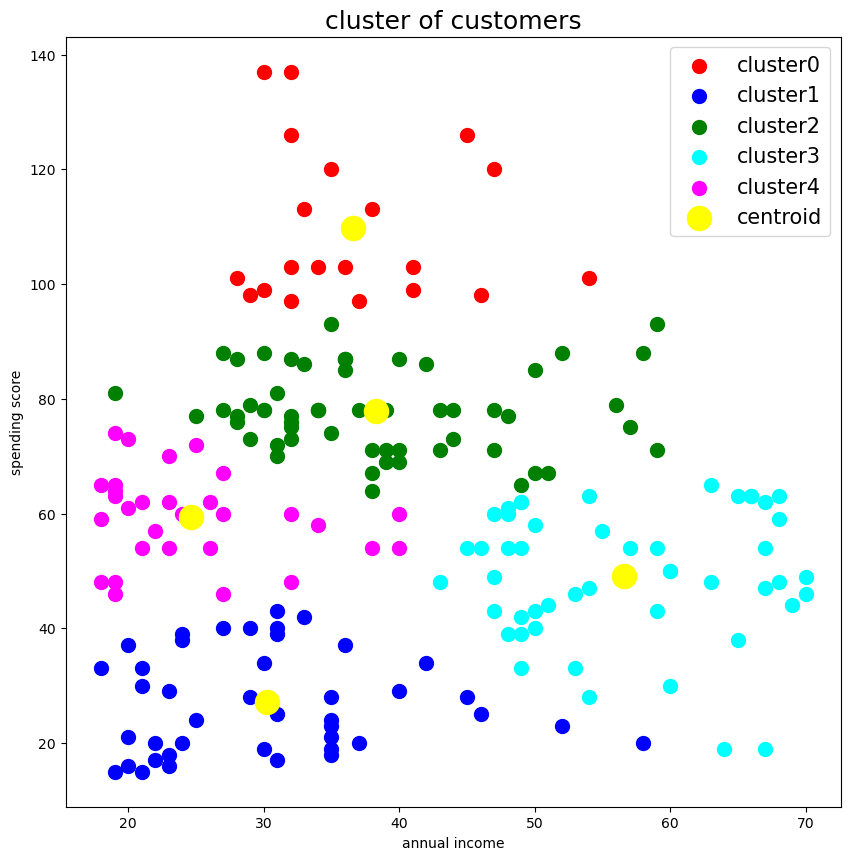

In [17]:
# plt.savefig('subplot.jpg')

plt.figure(1,figsize=(10,10)) #new figure (figure #1) sized 10x10 inches — makes the plot large and easy to read.
#filter rows of X, then taking column 0 ,gives x-coordinates of all points in cluster 0

plt.scatter(X[k_pred==0,0], X[k_pred ==0,1],s = 100 ,c = 'red', label = 'cluster0')

plt.scatter(X[k_pred==1,0], X[k_pred ==1,1],s = 100 ,c = 'blue', label = 'cluster1')

plt.scatter(X[k_pred==2,0], X[k_pred ==2,1],s = 100 ,c = 'green', label = 'cluster2')

plt.scatter(X[k_pred==3,0], X[k_pred ==3,1],s = 100 ,c = 'cyan', label = 'cluster3')

plt.scatter(X[k_pred==4,0], X[k_pred ==4,1],s = 100 ,c = 'magenta', label = 'cluster4')


plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s = 300 ,c = 'yellow', label = 'centroid')

#changes global default settings for matplotlib plots,run command params
plt.rcParams.update({'font.size': 15})

plt.title('cluster of customers')
plt.xlabel('annual income')
plt.ylabel('spending score')
plt.legend()
plt.show()

In [18]:
df['cluster'] = pd.DataFrame(k_pred)

In [19]:
df.cluster.value_counts()

cluster
2    59
3    49
1    42
4    30
0    20
Name: count, dtype: int64

In [ ]:
df

In [20]:
cluster0 = df[df['cluster']==0]
cluster1 = df[df['cluster']==1]
cluster2 = df[df['cluster']==2]
cluster3 = df[df['cluster']==3]
cluster4 = df[df['cluster']==4]

In [21]:
cluster0

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
180,181,Female,37,97,32,0
181,182,Female,32,97,86,0
182,183,Male,46,98,15,0
183,184,Female,29,98,88,0
184,185,Female,41,99,39,0
185,186,Male,30,99,97,0
186,187,Female,54,101,24,0
187,188,Male,28,101,68,0
188,189,Female,41,103,17,0
189,190,Female,36,103,85,0


In [22]:
c=pd.crosstab(df.Genre,df.cluster,margins = True) #crosstab method counts of how two categorical variables relate to each other.
c

cluster,0,1,2,3,4,All
Genre,,,,,,
Female,13,28,30,25,16,112
Male,7,14,29,24,14,88
All,20,42,59,49,30,200


<Axes: xlabel='Genre'>

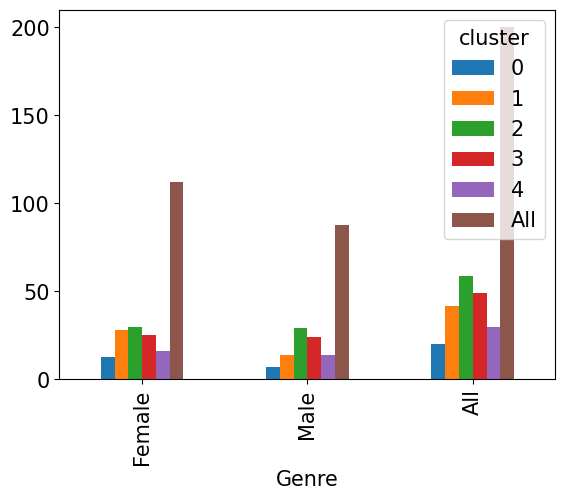

In [23]:
c.plot(kind='bar',stacked=False)

In [24]:
pd.crosstab(df.Age,df.cluster,margins = True)

cluster,0,1,2,3,4,All
Age,,,,,,
18,0,1,0,0,3,4
19,0,1,1,0,6,8
20,0,3,0,0,2,5
21,0,3,0,0,2,5
22,0,2,0,0,1,3
23,0,3,0,0,3,6
24,0,3,0,0,1,4
25,0,1,1,0,1,3
26,0,0,0,0,2,2


In [27]:
pd.crosstab(df['Annual Income (k$)'],df.cluster,margins = True)

cluster,0,1,2,3,4,All
Annual Income (k$),,,,,,
15,0,2,0,0,0,2
16,0,2,0,0,0,2
17,0,2,0,0,0,2
18,0,2,0,0,0,2
19,0,2,0,2,0,4
...,...,...,...,...,...,...
113,2,0,0,0,0,2
120,2,0,0,0,0,2
126,2,0,0,0,0,2


In [30]:
#g=df.groupby('cluster').mean()
g = df.groupby('cluster').mean(numeric_only=True)
g

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,,
0,190.500000,36.600000,109.700000,52.000000
1,25.238095,30.214286,27.071429,56.690476
2,149.949153,38.254237,77.915254,52.406780
3,71.102041,56.591837,49.061224,43.489796
4,96.633333,24.633333,59.333333,46.533333


<Axes: xlabel='cluster'>

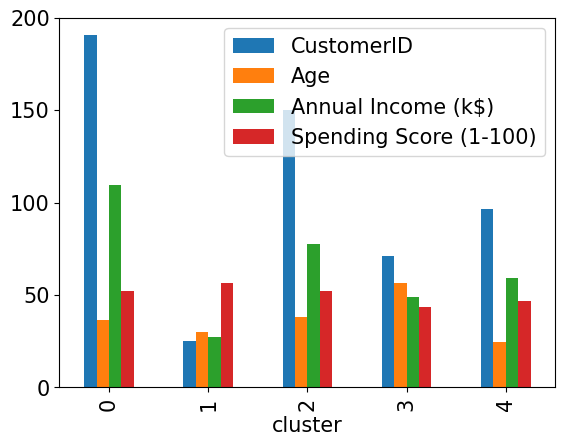

In [31]:
g.plot(kind='bar',stacked=False)

# TO save cluser wise data

In [32]:
cluster1.to_csv('cluster1.csv')